*Carga.*

In [1]:
import pandas as pd

# Lista con las rutas de los 5 CSVs
archivos = ["C:/Users/OAD/Documents/Practice/RAW/stardewvalley/fall_crops_info.csv",
     "C:/Users/OAD/Documents/Practice/RAW/stardewvalley/special_crops_info.csv",
     "C:/Users/OAD/Documents/Practice/RAW/stardewvalley/spring_crops_info.csv",
     "C:/Users/OAD/Documents/Practice/RAW/stardewvalley/summer_crops_info.csv",
     "C:/Users/OAD/Documents/Practice/RAW/stardewvalley/winter_crops_info.csv"]

# Leemos cada archivo y los guardamos temporalmente en una lista
lista_dataframes = []
for archivo in archivos:
    df_temporal = pd.read_csv(archivo)
    lista_dataframes.append(df_temporal)

# Concatenamos (unimos verticalmente) todos los DataFrames en uno solo
df_completo = pd.concat(lista_dataframes, ignore_index=True)

# Ver el resultado unificado
print(f"Total de filas combinadas: {len(df_completo)}")

Total de filas combinadas: 54


In [2]:
df_completo.sample(10)

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,season
23,Cauliflower,"Valuable, but slow-growing. Despite its pale c...",12,0,80,175,NO,YES,Spring
6,Eggplant,A rich and wholesome relative of the tomato. D...,5,5,20,60,YES,YES,Fall
16,Fiber Seeds,"Plant these to grow fiber crops, useful for cr...",7,0,5,1,NO,NO,Any
33,Unmilled Rice (Irrigated),Rice in its rawest form. Run this through a mi...,6,0,40,30,NO,NO,Spring
20,Tea Leaves,"The young leaves of a tea plant, used to make ...",20,7,50,50,YES,NO,Any
10,Sunflower,A common misconception is that the flower turn...,8,0,200,80,NO,NO,Fall
30,Rhubarb,"The stalks are extremely tart, but make a grea...",13,0,100,220,NO,YES,Spring
15,Cactus Fruit,The sweet fruit of the prickly pear cactus.,12,3,150,75,YES,YES,Any
52,Wheat,One of the most widely cultivated grains. Make...,4,0,10,25,NO,NO,Summer
37,Corn,"One of the most popular grains. The sweet, fre...",14,4,150,50,YES,YES,Summer


In [3]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   crop_name          54 non-null     object
 1   description        54 non-null     object
 2   days_to_grow       54 non-null     int64 
 3   regrowth           54 non-null     int64 
 4   seed_price         54 non-null     int64 
 5   sell_price         54 non-null     int64 
 6   multiple_harvests  54 non-null     object
 7   edible             54 non-null     object
 8   season             54 non-null     object
dtypes: int64(4), object(5)
memory usage: 3.9+ KB


In [4]:
df_completo["season"].value_counts()

season
Summer    18
Fall      14
Spring    14
Any        7
Winter     1
Name: count, dtype: int64

*Excluimos items que a pesar de son plantables no son considerados dentro de las mecanicas de granja estandar.*

In [5]:
excluir = ["Mixed Seeds", "Mixed Flower Seeds", "Qi Fruit", "Fiber Seeds"]
df_completo = df_completo[~df_completo["crop_name"].isin(excluir)].copy()

*Creamos DataFrames por temporada.*

# ¿Que Crops da más beneficio por venta a largo y corto plazo? #

*Crops por temporada con más beneficio en la primera recolección.*

In [6]:
df_crops_no_regrowth = df_completo[df_completo["multiple_harvests"] == "NO"].copy() #Filtramos crops no renovables.
df_crops_no_regrowth["ganancia"] = (df_crops_no_regrowth["sell_price"] - df_crops_no_regrowth["seed_price"]) #Creamos la columna "ganancia"

In [7]:
df_crops_no_regrowth_ordered = df_crops_no_regrowth.sort_values(by=["season", "ganancia"], ascending=[True, False]) #Ordenado.
df_crops_no_regrowth_top_3 = df_crops_no_regrowth_ordered.groupby("season").head(3).copy() #Top 3 por season.

*Top 3 crops por temporada con mayor margen de venta.*

In [8]:
df_crops_no_regrowth_top_3

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,season,ganancia
11,Sweet Gem Berry,It's by far the sweetest thing you've ever sme...,24,0,1000,3000,NO,NO,Fall,2000
9,Pumpkin,"A fall favorite, grown for its crunchy seeds a...",13,0,100,320,NO,YES,Fall,220
1,Artichoke,The bud of a thistle plant. The spiny outer le...,8,0,30,160,NO,YES,Fall,130
30,Rhubarb,"The stalks are extremely tart, but make a grea...",13,0,100,220,NO,YES,Spring,120
23,Cauliflower,"Valuable, but slow-growing. Despite its pale c...",12,0,80,175,NO,YES,Spring,95
27,Kale,The waxy leaves are great in soups and stir fr...,6,0,70,110,NO,YES,Spring,40
45,Starfruit,"An extremely juicy fruit that grows in hot, hu...",13,0,400,750,NO,YES,Summer,350
40,Melon,"A cool, sweet summer treat.",12,0,80,250,NO,YES,Summer,170
44,Red Cabbage,Often used in salads and coleslaws. The color ...,9,0,100,260,NO,YES,Summer,160
53,Powdermelon,Named for the powdery coating that forms on th...,7,0,70,70,NO,YES,Winter,0


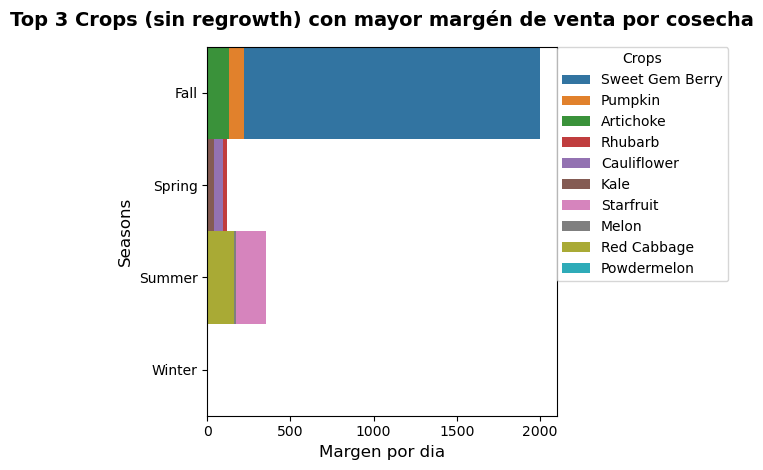

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(
    data=df_crops_no_regrowth_top_3,
    x="ganancia",
    y="season",
    hue="crop_name",
    palette="tab10",
    dodge=False,
    width=1,
)

plt.title("Top 3 Crops (sin regrowth) con mayor margén de venta por cosecha", fontsize = 14, fontweight="bold", pad=15)
plt.xlabel("Margen por dia", fontsize=12)
plt.ylabel("Seasons", fontsize=12)

plt.legend(title="Crops", bbox_to_anchor=(1, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

**Top 1 de Crops (sin regrowth) por cosecha:**
- Any: N/A
- Fall: Sweet Gem Berry ($2000)
- Spring: Rhubarb ($120)
- Summer: Starfruit ($350)
- Winter: N/A

*Crops por temporada con más beneficio de recolección renovable.*

In [10]:
df_crops_regrowth = df_completo[df_completo["multiple_harvests"] == "YES"].copy()  #Filtramos crops no renovables.

df_crops_regrowth["dias_de_regrowth"] = (28 - df_crops_regrowth["days_to_grow"]).astype(int) #Dias en que las crops realmente van a hacer regrowth. Transformamos a int para ignorar los decimales (basicamente truncar).
df_crops_regrowth["regrowths"] = (df_crops_regrowth["dias_de_regrowth"] / df_crops_regrowth["regrowth"]).astype(int)

df_crops_regrowth["ingreso_por_1_cosecha"] = (df_crops_regrowth["sell_price"] - df_crops_regrowth["seed_price"]) #dinero por la primera cosecha
df_crops_regrowth["ingreso_por_regrowths"] = df_crops_regrowth["regrowths"] * df_crops_regrowth["sell_price"] #dinero de cosechas posteriores
df_crops_regrowth["ganancia_total_por_mes"] = df_crops_regrowth["ingreso_por_1_cosecha"] + df_crops_regrowth["ingreso_por_regrowths"]    #Creamos la columna "dinero_por_mes"

In [11]:
df_crops_regrowth_ordered = df_crops_regrowth.sort_values(by=["season", "ganancia_total_por_mes"], ascending=[True, False]) #Ordenado.
df_crops_regrowth_top_3 = df_crops_regrowth_ordered.groupby("season").head(3).copy() #Top 3 por season.

In [12]:
df_crops_regrowth_top_3

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,season,dias_de_regrowth,regrowths,ingreso_por_1_cosecha,ingreso_por_regrowths,ganancia_total_por_mes
14,Ancient Fruit,A rare and exotic fruit with a mysterious orig...,28,7,100,550,YES,YES,Any,0,0,450,0,450
15,Cactus Fruit,The sweet fruit of the prickly pear cactus.,12,3,150,75,YES,YES,Any,16,5,-75,375,300
20,Tea Leaves,"The young leaves of a tea plant, used to make ...",20,7,50,50,YES,NO,Any,8,1,0,50,50
8,Grape,A sweet cluster of fruit.,10,3,60,80,YES,YES,Fall,18,6,20,480,500
6,Eggplant,A rich and wholesome relative of the tomato. D...,5,5,20,60,YES,YES,Fall,23,4,40,240,280
5,Cranberries,These tart red berries are a traditional winte...,7,5,240,75,YES,YES,Fall,21,4,-165,300,135
31,Strawberry,"A sweet, juicy favorite with an appealing red ...",8,4,100,120,YES,YES,Spring,20,5,20,600,620
26,Green Bean,"A juicy little bean with a cool, crisp snap.",10,3,60,40,YES,YES,Spring,18,6,-20,240,220
24,Coffee Bean,Plant in spring or summer to grow a coffee pla...,10,2,100,15,YES,NO,Spring,18,9,-85,135,50
38,Hops,"A bitter, tangy flower used to flavor beer.",11,1,60,25,YES,NO,Summer,17,17,-35,425,390


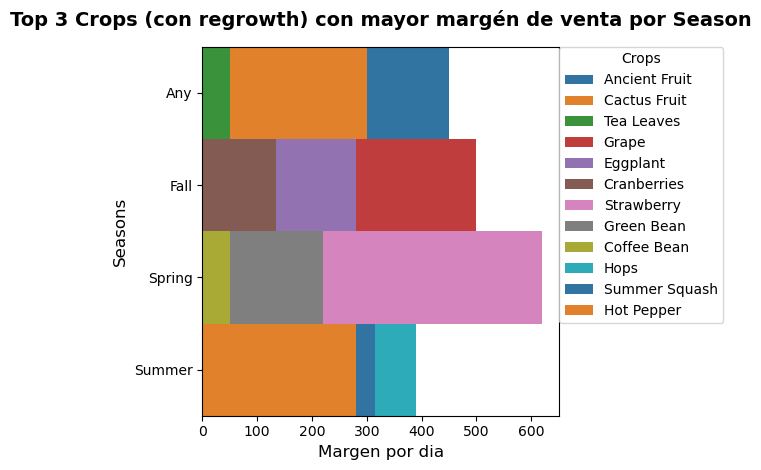

In [13]:
sns.barplot(
    data=df_crops_regrowth_top_3,
    x="ganancia_total_por_mes",
    y="season",
    hue="crop_name",
    palette="tab10",
    dodge=False,
    width=1,
)

plt.title("Top 3 Crops (con regrowth) con mayor margén de venta por Season", fontsize = 14, fontweight="bold", pad=15)
plt.xlabel("Margen por dia", fontsize=12)
plt.ylabel("Seasons", fontsize=12)

plt.legend(title="Crops", bbox_to_anchor=(1, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

**Top 1 de Crops (con regrowth) por Season:**
- Any: Ancient Fruit ($450)
- Fall: Grape ($500)
- Spring: Strawberry ($620)
- Summer: Hops ($390)
- Winter: N/A

Y si replantamos Crops de un una sola cosecha ¿Obtendriamos más en el mes?

In [14]:
df_crops_no_regrowth_replanted = df_crops_no_regrowth[df_crops_no_regrowth["days_to_grow"] != 0].copy() #Descartamos 0 debido a que vamos a dividir y eso da error fatal.
df_crops_no_regrowth_replanted["replants"] =  (28 / df_crops_no_regrowth_replanted["days_to_grow"]).astype(int) #Calculamos las veces que es posible replantar un Crop. (Int para truncar)

In [15]:
df_crops_no_regrowth_replanted["replant_ganancia"] = (df_crops_no_regrowth_replanted["sell_price"] - df_crops_no_regrowth_replanted["seed_price"]) * df_crops_no_regrowth_replanted["replants"] #Creamos la columna ganancia por replante.
df_crops_no_regrowth_replanted["ganancia_total_por_mes"] = df_crops_no_regrowth_replanted["replant_ganancia"] * df_crops_no_regrowth_replanted["replants"] #Calculamos la ganancia total de la season.

In [16]:
df_crops_no_regrowth_replanted_ordered = df_crops_no_regrowth_replanted.sort_values(by=["season", "ganancia_total_por_mes"], ascending=[True, False]) #Ordenado.
df_crops_no_regrowth_replanted_top_3 = df_crops_no_regrowth_replanted_ordered.groupby("season").head(3).copy() #Top 3 por season.

In [17]:
df_crops_no_regrowth_replanted_top_3

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,season,ganancia,replants,replant_ganancia,ganancia_total_por_mes
11,Sweet Gem Berry,It's by far the sweetest thing you've ever sme...,24,0,1000,3000,NO,NO,Fall,2000,1,2000,2000
3,Bok Choy,The leafy greens and fibrous stalks are health...,4,0,50,80,NO,YES,Fall,30,7,210,1470
0,Amaranth,A purple grain cultivated by an ancient civili...,7,0,70,150,NO,NO,Fall,80,4,320,1280
25,Garlic,Adds a wonderful zestiness to dishes. High qua...,4,0,40,60,NO,YES,Spring,20,7,140,980
28,Parsnip,A spring tuber closely related to the carrot. ...,4,0,20,35,NO,YES,Spring,15,7,105,735
27,Kale,The waxy leaves are great in soups and stir fr...,6,0,70,110,NO,YES,Spring,40,4,160,640
44,Red Cabbage,Often used in salads and coleslaws. The color ...,9,0,100,260,NO,YES,Summer,160,3,480,1440
45,Starfruit,"An extremely juicy fruit that grows in hot, hu...",13,0,400,750,NO,YES,Summer,350,2,700,1400
43,Radish,A crisp and refreshing root vegetable with hin...,6,0,40,90,NO,YES,Summer,50,4,200,800
53,Powdermelon,Named for the powdery coating that forms on th...,7,0,70,70,NO,YES,Winter,0,4,0,0


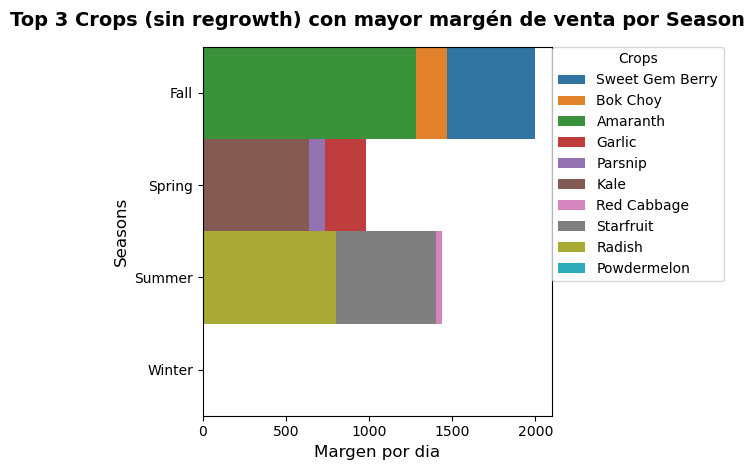

In [18]:
sns.barplot(
    data=df_crops_no_regrowth_replanted_top_3,
    x="ganancia_total_por_mes",
    y="season",
    hue="crop_name",
    palette="tab10",
    dodge=False,
    width=1,
)

plt.title("Top 3 Crops (sin regrowth) con mayor margén de venta por Season", fontsize = 14, fontweight="bold", pad=15)
plt.xlabel("Margen por dia", fontsize=12)
plt.ylabel("Seasons", fontsize=12)

plt.legend(title="Crops", bbox_to_anchor=(1, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

**Top 1 de Crops (sin regrowth) por Season:**
- Any: Mixed Flower Seeds ($320)
- Fall: Sweet Gem Berry ($2000)
- Spring: Garlic ($640)
- Summer: Red Cabbage ($1440)
- Winter: N/A

# Entonces ¿Cual da mas ganancia en general? #

In [19]:
df_full = pd.concat([df_crops_no_regrowth_replanted, df_crops_regrowth], axis=0,ignore_index=True).fillna("N/A")
df_full.columns.to_list()

['crop_name',
 'description',
 'days_to_grow',
 'regrowth',
 'seed_price',
 'sell_price',
 'multiple_harvests',
 'edible',
 'season',
 'ganancia',
 'replants',
 'replant_ganancia',
 'ganancia_total_por_mes',
 'dias_de_regrowth',
 'regrowths',
 'ingreso_por_1_cosecha',
 'ingreso_por_regrowths']

In [20]:
df_full.shape
df_full.sort_values(by="season", inplace=True)

In [21]:
df_full_ordered = df_full.sort_values(by=["season", "ganancia_total_por_mes"], ascending=[True, False]) #Ordenado.
df_full_top_3 = df_full_ordered.groupby("season").head(3).copy() #Top 3 por season.

In [22]:
df_full_top_3

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,season,ganancia,replants,replant_ganancia,ganancia_total_por_mes,dias_de_regrowth,regrowths,ingreso_por_1_cosecha,ingreso_por_regrowths
37,Ancient Fruit,A rare and exotic fruit with a mysterious orig...,28,7,100,550,YES,YES,Any,N/A,N/A,N/A,450,0.0,0.0,450.0,0.0
38,Cactus Fruit,The sweet fruit of the prickly pear cactus.,12,3,150,75,YES,YES,Any,N/A,N/A,N/A,300,16.0,5.0,-75.0,375.0
39,Tea Leaves,"The young leaves of a tea plant, used to make ...",20,7,50,50,YES,NO,Any,N/A,N/A,N/A,50,8.0,1.0,0.0,50.0
7,Sweet Gem Berry,It's by far the sweetest thing you've ever sme...,24,0,1000,3000,NO,NO,Fall,2000.0,1.0,2000.0,2000,N/A,N/A,N/A,N/A
3,Bok Choy,The leafy greens and fibrous stalks are health...,4,0,50,80,NO,YES,Fall,30.0,7.0,210.0,1470,N/A,N/A,N/A,N/A
0,Amaranth,A purple grain cultivated by an ancient civili...,7,0,70,150,NO,NO,Fall,80.0,4.0,320.0,1280,N/A,N/A,N/A,N/A
13,Garlic,Adds a wonderful zestiness to dishes. High qua...,4,0,40,60,NO,YES,Spring,20.0,7.0,140.0,980,N/A,N/A,N/A,N/A
15,Parsnip,A spring tuber closely related to the carrot. ...,4,0,20,35,NO,YES,Spring,15.0,7.0,105.0,735,N/A,N/A,N/A,N/A
14,Kale,The waxy leaves are great in soups and stir fr...,6,0,70,110,NO,YES,Spring,40.0,4.0,160.0,640,N/A,N/A,N/A,N/A
25,Red Cabbage,Often used in salads and coleslaws. The color ...,9,0,100,260,NO,YES,Summer,160.0,3.0,480.0,1440,N/A,N/A,N/A,N/A


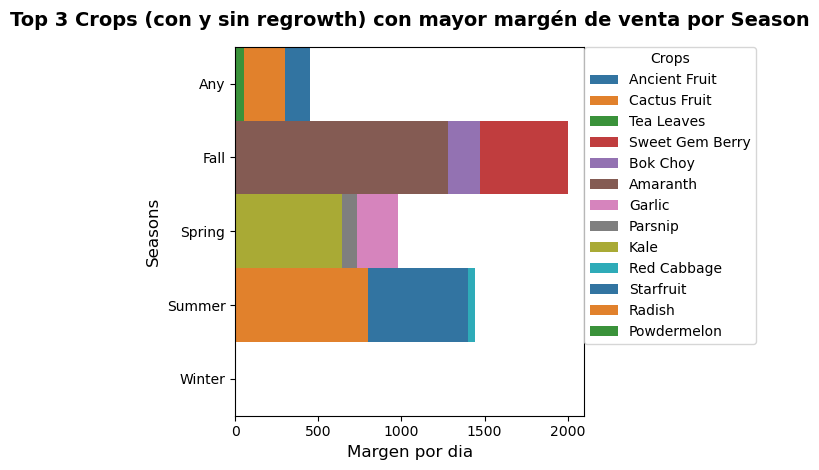

In [23]:
sns.barplot(
    data=df_full_top_3,
    x="ganancia_total_por_mes",
    y="season",
    hue="crop_name",
    palette="tab10",
    dodge=False,
    width=1,
)

plt.title("Top 3 Crops (con y sin regrowth) con mayor margén de venta por Season", fontsize = 14, fontweight="bold", pad=15)
plt.xlabel("Margen por dia", fontsize=12)
plt.ylabel("Seasons", fontsize=12)

plt.legend(title="Crops", bbox_to_anchor=(1, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

**Top 1 de Crops (con y sin regrowth) por Season:**
- Any: Ancient Fruit ($450)
- Fall: Sweet Gem Berry ($2000)
- Spring: Garlic ($980)
- Summer: Red Cabbage ($1440)
- Winter: N/A

*Return Of Investment.*

In [24]:
df_full["ROI"] = df_full["ganancia_total_por_mes"] / df_full["seed_price"]

In [25]:
df_full_roi_ordered = df_full.sort_values(by=["season", "ROI"], ascending=[True, False]) #Ordenado.
df_full_top_3_roi = df_full_roi_ordered.groupby("season").head(3).copy() #Top 3 por season.

In [26]:
df_full_top_3_roi

,crop_name,description,days_to_grow,regrowth,seed_price,sell_price,multiple_harvests,edible,season,ganancia,replants,replant_ganancia,ganancia_total_por_mes,dias_de_regrowth,regrowths,ingreso_por_1_cosecha,ingreso_por_regrowths,ROI
37,Ancient Fruit,A rare and exotic fruit with a mysterious orig...,28,7,100,550,YES,YES,Any,N/A,N/A,N/A,450,0.0,0.0,450.0,0.0,4.500000
38,Cactus Fruit,The sweet fruit of the prickly pear cactus.,12,3,150,75,YES,YES,Any,N/A,N/A,N/A,300,16.0,5.0,-75.0,375.0,2.000000
39,Tea Leaves,"The young leaves of a tea plant, used to make ...",20,7,50,50,YES,NO,Any,N/A,N/A,N/A,50,8.0,1.0,0.0,50.0,1.000000
8,Wheat,One of the most widely cultivated grains. Make...,4,0,10,25,NO,NO,Fall,15.0,7.0,105.0,735,N/A,N/A,N/A,N/A,73.500000
2,Beet,"A sweet and earthy root vegetable. As a bonus,...",6,0,20,100,NO,YES,Fall,80.0,4.0,320.0,1280,N/A,N/A,N/A,N/A,64.000000
1,Artichoke,The bud of a thistle plant. The spiny outer le...,8,0,30,160,NO,YES,Fall,130.0,3.0,390.0,1170,N/A,N/A,N/A,N/A,39.000000
15,Parsnip,A spring tuber closely related to the carrot. ...,4,0,20,35,NO,YES,Spring,15.0,7.0,105.0,735,N/A,N/A,N/A,N/A,36.750000
13,Garlic,Adds a wonderful zestiness to dishes. High qua...,4,0,40,60,NO,YES,Spring,20.0,7.0,140.0,980,N/A,N/A,N/A,N/A,24.500000
10,Blue Jazz,The flower grows in a sphere to invite as many...,7,0,30,50,NO,NO,Spring,20.0,4.0,80.0,320,N/A,N/A,N/A,N/A,10.666667
31,Wheat,One of the most widely cultivated grains. Make...,4,0,10,25,NO,NO,Summer,15.0,7.0,105.0,735,N/A,N/A,N/A,N/A,73.500000


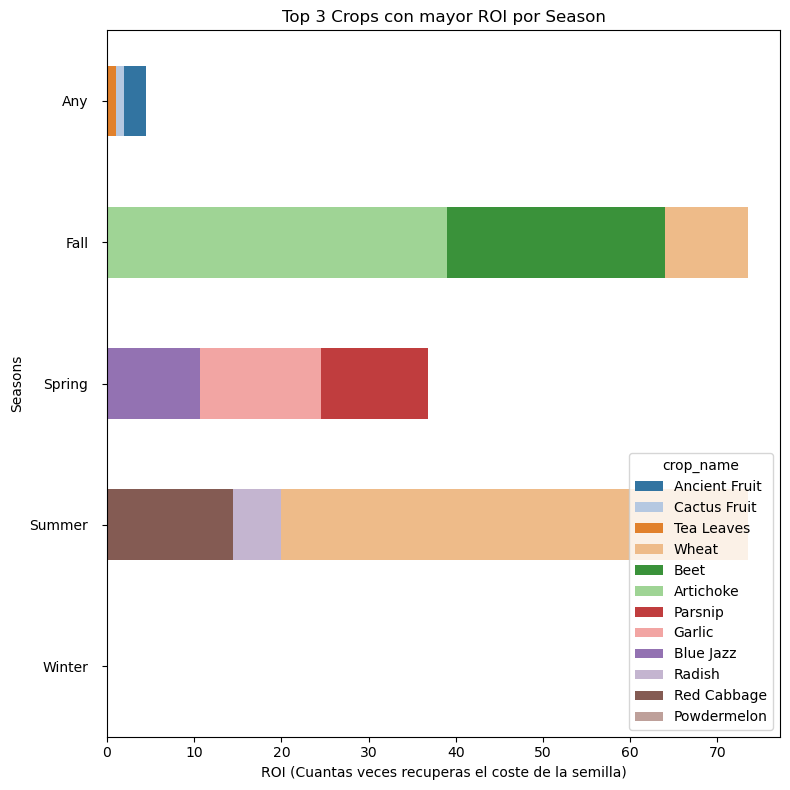

In [27]:
plt.figure(figsize=(8, 8))

ax = sns.barplot(
    data=df_full_top_3_roi,
    x="ROI",
    y="season",
    hue="crop_name",
    palette="tab20",
    dodge=False,
    width=0.5
)
ax.tick_params(axis="y", which="major", pad=10)
plt.title("Top 3 Crops con mayor ROI por Season")
plt.xlabel("ROI (Cuantas veces recuperas el coste de la semilla)")
plt.ylabel("Seasons")

plt.tight_layout()
plt.show()

# En sintesis. #
- Ganancia y ROI: Los cultivos con mayor precio de venta son tambien los más caros de producir. Por ende, para comenzar, se recomiendan utilizar cultivos de bajo coste que retornen la inversión multiples veces.
- Seasons: Las temporadas de mayor retorno son "Fall" y "Summer" concentrando por mucho cultivos de alto rendimiento y crops con "regrowth".
- Regrowth: Los cultivos regrowth se transforman en flujo de caja más continuo y proyecta mucho más su rendimiento mensual al no tener que volver a comprarlos.
- Estrategia de juego año 1: Se recomienda durante el año 1 de juego priorizar cultivos de bajo coste y alta frecuencia de cosecha. Este enfoque en ROI permitirá capitalizar rapidamente al llegar al año 2 o posterior.
- Estrategia de juego año 2: Se recomienda durante el año 2 de juego inclinarse a cultivos de margen masivo y la optimización del espacio de los cultivos. Asimismo, considerar barriles para hacer vinos y asi extraer más plusvalia de la fruta cosechada.